### setup

In [1]:
%matplotlib inline

from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
from IPython.display import Image, display

# dataset dirs follow conf/dataset/*/default.yaml: ${root}/${dataset.dir}
DATA = Path('/home/nik/workspace/ImperialWork/msc_project/SyncNetProject/data')
SOC_NPZ = DATA / 'sort_of_clevr-seed1-train36000-test1000-q10-t-1' / 'test.npz'
SQOOP_NPZ = DATA / 'sqoop-seed0-train1080000-test25600-rhs18' / 'val_seen.npz'

OUT_DIR = Path('./outputs') / 'figures'
CHAP_DATASETS = OUT_DIR / 'chap:datasets'
CHAP_RESULTS = OUT_DIR / 'chap:results'
CHAP_DATASETS.mkdir(parents=True, exist_ok=True)
CHAP_RESULTS.mkdir(parents=True, exist_ok=True)

mpl.rcParams.update({
    'font.family': 'serif',
    'font.serif': ['DejaVu Serif'],
    'font.size': 9,
    'axes.labelsize': 9,
    'axes.titlesize': 9,
    'xtick.labelsize': 8,
    'ytick.labelsize': 8,
    'figure.dpi': 140,
    'savefig.dpi': 400,
    'savefig.bbox': 'tight',
    'savefig.pad_inches': 0.02,
})


def save_show(fig, name, dir, screen_dpi=110):
    path = dir / f'{name}.png'
    fig.savefig(path)
    width = int(fig.get_size_inches()[0] * screen_dpi)   # show at screen size, not the 400-dpi pixel size
    plt.close(fig)
    display(Image(path, width=width))

### Sort-of-CLEVR example

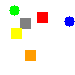

In [2]:
soc = np.load(SOC_NPZ, allow_pickle=False)

scene = 0
plt.imsave(CHAP_DATASETS / 'soc_example.png', soc['images'][scene][..., ::-1])   # stored BGR (cv2)
display(Image(CHAP_DATASETS / 'soc_example.png'))

### SQOOP examples

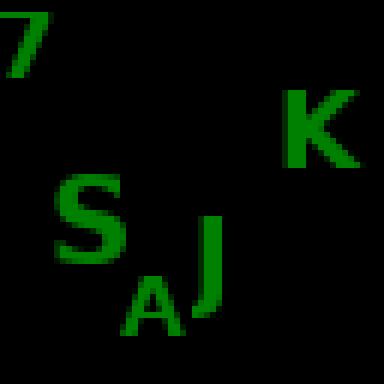

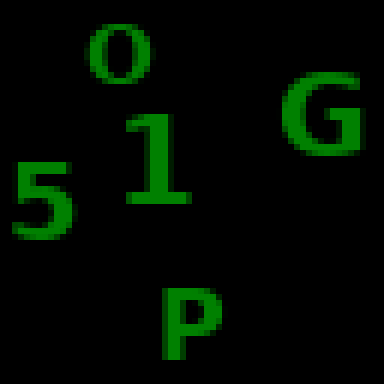

In [3]:
sq = np.load(SQOOP_NPZ, allow_pickle=True)

for i in range(2):
    plt.imsave(CHAP_DATASETS / f'sqoop_example_{i}.png', np.kron(sq['images'][i], np.ones((6, 6, 1), dtype=np.uint8)))
    display(Image(CHAP_DATASETS / f'sqoop_example_{i}.png'))

### results — run registry

Every result cell is one `cfg_hash` (the 10-char id in the `cfg:…` tag / `config.cfg_hash`; seeded reruns of a
config share it, so they aggregate automatically). `None` = not run yet — the cell is left out of the figures.

In [ ]:
ENTITY, TAG = 'niks_priv', 'v16'
SOC, SQ = 'sort_of_clevr', 'sqoop'
PAIR_VARIETY = [1, 2, 4, 8, 18, 35]
T_TEST = [0, 1, 2, 4, 6, 8, 12, 16]                # T values evaluated by the t_variance callback

MAIN = {
    SOC: {                       # label -> cfg_hash
        'Q-Only':      None,
        'CNN+MLP':     None,
        'Conv+LSTM':   None,
        'RelNet':      None,
        'FiLM':        None,
        'Transformer': None,
        'Workspace':   None,
        'SyncNet':     '28033fa5ab',                # sync/hybrids/identity_spatial
    },
    SQ: {                        # label -> {pair variety -> cfg_hash}
        'Q-Only':      {1: 'da868e47f3', 2: '8c385b2059', 4: 'b53f5ecb08', 8: 'c7cfb0dd1c', 18: 'd640141c57', 35: 'a09acf017b'},
        'CNN+MLP':     {1: None,         2: None,         4: None,         8: None,         18: None,         35: None},
        'Conv+LSTM':   {1: '4dd2f8a5f6', 2: 'b838865278', 4: '11380cec6a', 8: '125ce8d50e', 18: '6828367e4c', 35: 'd6cbb5b004'},
        'RelNet':      {1: 'd91b42c323', 2: '41515ce582', 4: '46ef70288f', 8: 'f15b7d0159', 18: 'fd877702cb', 35: '18a92d8762'},
        'FiLM':        {1: '48c351e38b', 2: 'cbbfbd61a7', 4: '13e08caaa4', 8: '70f71488ff', 18: '4cf87adb37', 35: 'dd57cc6026'},
        'Transformer': {1: 'e5acac883a', 2: 'bd94a19a03', 4: '10eb8e1433', 8: '007a9674ee', 18: '17110fa882', 35: '13222c0aab'},
        'Workspace':   {1: '58a944c267', 2: '61a49532b2', 4: 'd12abb2e78', 8: 'fe996cfc81', 18: 'f3743655aa', 35: 'fa00371d63'},
        'SyncNet':     {1: None,         2: None,         4: None,         8: None,         18: '9f0c939a32', 35: None},
        #               sync/hybrids/identity_partition_cnnenc
    },
}
FLOOR_MODEL = 'Q-Only'           # subtracted in the "accuracy above floor" plots (no-op until it has a run)

# Sort-of-CLEVR sweeps: x -> cfg_hash.  t_test is one run: its t_variance/* summaries give the sweep.
ABLATIONS = {
    't_train':   {1: None, 2: None, 4: None, 6: None, 8: '28033fa5ab', 12: None},
    'n_modules': {1: None, 2: None, 4: None, 6: '28033fa5ab', 8: None, 12: None},
    'phase_dim': {2: None, 3: None, 4: None, 6: '28033fa5ab', 8: None, 12: None},
    't_test':    '28033fa5ab',
}

# wandb summary columns behind each reported number
METRICS = {
    SOC: {'Overall': 'test_callbacks/accuracy', 'Non-relational': 'test_callbacks/non_relational_accuracy',
          'Binary': 'test_callbacks/binary_accuracy', 'Ternary': 'test_callbacks/ternary_accuracy'},
    SQ:  {'validation': 'eval_callbacks/accuracy', 'held-out': 'test_callbacks/accuracy'},
}
SUBTYPES = {                      # Table B.1 rows -> wandb column stem
    'Non-relational': {'Query shape': 'query_shape', 'Left of centre': 'left_of_centre', 'Top half': 'top_half'},
    'Binary':         {'Closest shape': 'closest_shape', 'Furthest shape': 'furthest_shape', 'Count same shape': 'count_same_shape'},
    'Ternary':        {'Count in box': 'count_in_box', 'On band': 'on_band', 'Count obtuse': 'count_obtuse'},
}
T_VARIANCE = {'Overall': 't_variance/acc_mean_T{}', 'Binary': 't_variance/binary_mean_T{}', 'Ternary': 't_variance/ternary_mean_T{}'}
FAMILIES = list(METRICS[SOC])


### results — pull runs from wandb

One DataFrame per project, one row per finished run, config flattened to `model.name`-style columns plus every
scalar summary. Re-running reuses `RUNS` unless `REFRESH = True`. Falls back to `wandb_export_*.csv` next to the
notebook if the API is unreachable.

In [ ]:
REFRESH = False


def fetch(project):
    try:
        import wandb
        runs = wandb.Api(timeout=120).runs(f'{ENTITY}/{project}', filters={'tags': TAG, 'state': 'finished'})
        df = pd.json_normalize([{'created': str(r.created_at), **r.config,
                                 **{k: v for k, v in r.summary.items() if isinstance(v, (int, float))}}
                                for r in runs])
    except Exception as e:                              # offline / no API key
        print(f'{project}: wandb API unavailable ({e!r}); reading wandb_export_*.csv')
        df = pd.concat(pd.read_csv(p, low_memory=False) for p in Path('.').glob('wandb_export_*.csv'))
        df = df[(df['dataset.name'] == project) & (df['State'] == 'finished')].rename(columns={'Created': 'created'})
        df['cfg_hash'] = df['Tags'].str.extract(r'cfg:(\w{10})')[0]
    return df.sort_values('created').drop_duplicates(['cfg_hash', 'train.seed'], keep='last')   # latest run per seed


if REFRESH or 'RUNS' not in globals():
    RUNS = {ds: fetch(ds) for ds in (SOC, SQ)}
{ds: (len(df), df.cfg_hash.nunique()) for ds, df in RUNS.items()}


### results — the results table

`stat(dataset, cfg_hash, column)` is the one lookup every figure goes through: mean, sd and seed count (in %)
over the runs of that config. The two main tables below are built from it and show exactly what the figures use.

In [ ]:
def stat(dataset, cfg_hash, col):
    """(mean, sd, n) in % over the seeds of one config; (nan, nan, 0) if nothing to report."""
    df = RUNS[dataset]
    v = 100 * df.loc[df.cfg_hash == cfg_hash, col].dropna() if cfg_hash and col in df else pd.Series(dtype=float)
    return (v.mean(), v.std(ddof=1) if len(v) > 1 else 0.0, len(v)) if len(v) else (np.nan, np.nan, 0)


def fmt(m, s, n):
    return '—' if np.isnan(m) else f'{m:.1f} ± {s:.1f} ({n})'


soc_table = pd.DataFrame({fam: {label: fmt(*stat(SOC, h, col)) for label, h in MAIN[SOC].items()}
                          for fam, col in METRICS[SOC].items()})
sqoop_table = pd.DataFrame({f'variety {v}': {(label, split): fmt(*stat(SQ, by_v[v], col))
                                             for label, by_v in MAIN[SQ].items() for split, col in METRICS[SQ].items()}
                            for v in PAIR_VARIETY})
display(soc_table, sqoop_table)

# seeds per ablation cell
print({sweep: {x: stat(SOC, h, METRICS[SOC]['Overall'])[2] for x, h in cells.items()}
       for sweep, cells in ABLATIONS.items() if sweep != 't_test'})
print('t_test seeds with t_variance:', stat(SOC, ABLATIONS['t_test'], T_VARIANCE['Overall'].format(T_TEST[-1]))[2])


def floor(fam):
    return np.nan_to_num(stat(SOC, MAIN[SOC][FLOOR_MODEL], METRICS[SOC][fam])[0])


# canonical sweep values, read from the main run's config (defaults if the column is missing)
_main = RUNS[SOC][RUNS[SOC].cfg_hash == MAIN[SOC]['SyncNet']].iloc[0]
T_CANON, M_CANON, D_CANON = (int(_main[k]) if pd.notna(_main.get(k)) else d
                             for k, d in [('model.t_bus', 8), ('model.n_modules', 6), ('model.phase_dim', 6)])
T_CANON, M_CANON, D_CANON


### results — LaTeX tables

Every table in the thesis whose numbers come from runs, written to `chap:results/tables/*.tex` as a complete
`table` environment in the thesis's own markup so `main.tex` can `\input` them: the two Sort-of-CLEVR results
tables, the SQOOP table, the canonical configuration and the training configuration. Seed counts in the
captions are filled from the data.

In [ ]:
TEX = CHAP_RESULTS / 'tables'
TEX.mkdir(exist_ok=True)


def tex_cell(m, s, n=None):
    return '---' if np.isnan(m) else f'${m:.1f} \\pm {s:.1f}$'


def tex_model(label):
    return r'\textit{Q-Only}' if label == 'Q-Only' else rf'\textsc{{{label}}}'


def seeds_note(ns):
    ns = sorted({n for n in ns if n})
    return '---' if not ns else (str(ns[0]) if len(ns) == 1 else f'{ns[0]}--{ns[-1]}')


def write_tex(name, body):
    (TEX / f'{name}.tex').write_text(body)
    print(body)


def params(dataset, h):
    df = RUNS[dataset]
    n = df.loc[df.cfg_hash == h, 'n_params'].dropna() if h and 'n_params' in df else []
    return '---' if not len(n) else f'{n.iloc[0] / 1e6:.2f}M'


# ---- Table 5.1: Sort-of-CLEVR by family
rows, ns = [], []
for label, h in MAIN[SOC].items():
    st = [stat(SOC, h, col) for col in METRICS[SOC].values()]
    ns += [x[2] for x in st]
    rows.append(f'{tex_model(label)} & {params(SOC, h)} & ' + ' & '.join(tex_cell(*x) for x in st) + r' \\')
    if label in ('Q-Only', 'Workspace'):
        rows.append(r'\midrule')
write_tex('soc_results', r'''\begin{table}[htbp]
\centering
\caption{Sort-of-CLEVR: accuracy overall and by question family, in per cent. ''' + seeds_note(ns) + r''' seeds per cell; entries are mean$\,\pm\,$s.d.\ across seeds. The question-only row is the reference against which the remaining models are read. Per-subtype figures are given in Table~\ref{tab:soc-results-subtypes}.}
\label{tab:soc-results}
\setlength{\tabcolsep}{6pt}
\renewcommand{\arraystretch}{1.15}
\begin{tabular}{@{}lrcccc@{}}
\toprule
\textbf{Model} & \textbf{Params} & \textbf{Overall} & \textbf{Non-rel.} & \textbf{Binary} & \textbf{Ternary} \\
\midrule
''' + '\n'.join(rows) + r'''
\bottomrule
\end{tabular}
\end{table}
''')

In [ ]:
# ---- Table B.1: Sort-of-CLEVR by subtype
SUBTYPE_MODELS = ['Q-Only', 'CNN+MLP', 'RelNet', 'FiLM', 'Transformer', 'Workspace', 'SyncNet']
SUBTYPE_HEAD = {'Transformer': 'Trans.', 'Workspace': 'Works.'}


def subtype_row(name, col, bold=False, indent=False):
    st = [stat(SOC, MAIN[SOC][m], col) for m in SUBTYPE_MODELS]
    ns.extend(x[2] for x in st)
    label = (r'\hspace{1em}' if indent else '') + (rf'\textbf{{{name}}}' if bold else name)
    return f'{label} & ' + ' & '.join(tex_cell(*x) for x in st) + r' \\'


ns = []
rows = [subtype_row('Overall', METRICS[SOC]['Overall'], bold=True), r'\midrule']
for fam, subs in SUBTYPES.items():
    rows.append(subtype_row(fam, METRICS[SOC][fam], bold=True))
    rows += [subtype_row(name, f'test_callbacks/{key}_accuracy', indent=True) for name, key in subs.items()]
    rows.append(r'\midrule')
rows.pop()
write_tex('soc_results_subtypes', r'''\begin{table}[htbp]
\centering
\small
\caption{Sort-of-CLEVR: per-subtype accuracy, in per cent. ''' + seeds_note(ns) + r''' seeds per cell; entries are mean$\,\pm\,$s.d.\ across seeds. Family and overall aggregates are reproduced from Table~\ref{tab:soc-results}.}
\label{tab:soc-results-subtypes}
\setlength{\tabcolsep}{4pt}
\renewcommand{\arraystretch}{1.1}
\begin{tabular}{@{}l''' + 'c' * len(SUBTYPE_MODELS) + r'''@{}}
\toprule
\textbf{Question type} & ''' + ' & '.join(tex_model(SUBTYPE_HEAD.get(m, m)) for m in SUBTYPE_MODELS) + r''' \\
\cmidrule(l){2-''' + str(len(SUBTYPE_MODELS) + 1) + r'''}
''' + '\n'.join(rows) + r'''
\bottomrule
\end{tabular}
\end{table}
''')

In [ ]:
# ---- Table B.2: SQOOP by split and pair variety
rows, ns = [], []
for label, by_v in MAIN[SQ].items():
    for i, (split, col) in enumerate(METRICS[SQ].items()):
        st = [stat(SQ, by_v[v], col) for v in PAIR_VARIETY]
        ns += [x[2] for x in st]
        lead = rf'\multirow{{2}}{{*}}{{{tex_model(label)}}}' if i == 0 else ''
        rows.append(f'{lead} & {split} & ' + ' & '.join(tex_cell(*x) for x in st) + r' \\')
    rows.append(r'\midrule' if label == 'Q-Only' else r'\addlinespace')
rows.pop()
write_tex('sqoop_results', r'''\begin{table}[htbp]
\centering
\caption{SQOOP: accuracy on the validation and held-out splits at each setting of the pair variety, in per cent. ''' + seeds_note(ns) + r''' seeds per cell; entries are mean$\,\pm\,$s.d.\ across seeds. Chance is $50.0$ on every split. At a pair variety of $35$ every pair is a training pair, so the held-out column is an in-distribution control rather than a test of recombination.}
\label{tab:sqoop-results}
\setlength{\tabcolsep}{5pt}
\renewcommand{\arraystretch}{1.2}
\begin{tabular}{@{}lc''' + 'c' * len(PAIR_VARIETY) + r'''@{}}
\toprule
& & \multicolumn{''' + str(len(PAIR_VARIETY)) + r'''}{c}{\textbf{Pair variety}} \\
\cmidrule(l){3-''' + str(len(PAIR_VARIETY) + 2) + r'''}
\textbf{Model} & \textbf{Split} & ''' + ' & '.join(f'${v}$' for v in PAIR_VARIETY) + r''' \\
\midrule
''' + '\n'.join(rows) + r'''
\bottomrule
\end{tabular}
\end{table}
''')

In [ ]:
# ---- Tables 3.1 and C.1: canonical model and training configuration, read from the main run's config
def cfg(key, fmt=str):
    v = _main.get(key)
    return '---' if v is None or pd.isna(v) else fmt(v)


integer = lambda v: str(int(v))
CANONICAL = [   # (component, symbol, config key, formatter)
    ('Modules', '$M$', 'model.n_modules', integer),
    ('Phase dimension', '$d$', 'model.phase_dim', integer),
    ('Internal steps', '$T$', 'model.t_bus', integer),
    ('Step size', r'$\gamma$', 'model.dt', str),
    ('Module state', '$d_h$', 'model.module_dim', integer),
    ('Message', '$d_m$', 'model.msg_dim', integer),
    ('Oscillators per cell', '---', 'model.field_osc_dim', integer),
    ('Field steps', '$T_x$', 'model.field_T', integer),
    ('Field step size', r'$\gamma_x$', 'model.field_dt', str),
    ('Competition temperature', r'$\beta$', 'model.slot_beta', str),
    ('Spatial bias initialisation', '$b_k(p)$', 'model.claim_prior', str),
]
write_tex('canonical', r'''\begin{table}[ht]
\centering
\begin{tabular}{llc}
\toprule
Component & Symbol & Value \\
\midrule
''' + '\n'.join(f'{c} & {s} & {cfg(k, f)} ' + r'\\' for c, s, k, f in CANONICAL) + r'''
\bottomrule
\end{tabular}
\caption{The configuration used in every experiment. All results in Chapter~\ref{chap:results} are for this model; the ablations of Section~\ref{sec:methodology:ablations} each change one row.}
\label{tab:canonical}
\end{table}
''')

n_seeds = seeds_note([stat(ds, h, METRICS[ds]['Overall' if ds == SOC else 'held-out'])[2]
                      for ds in (SOC, SQ) for cells in MAIN[ds].values()
                      for h in (cells.values() if isinstance(cells, dict) else [cells])])
TRAINING = [
    ('Optimiser', cfg('optim.optimiser', lambda v: {'adamw': 'AdamW'}.get(v, v))),
    ('Learning rate', cfg('optim.lr', lambda v: f'${v:g}$')),
    ('Weight decay', cfg('optim.weight_decay', lambda v: f'${v:g}$')),
    ('Schedule', cfg('optim.lr_scheduler', lambda v: v.replace('_', '--'))),
    ('Warmup steps', cfg('optim.lr_scheduler_params.warmup_steps', lambda v: f'{int(v):,}')),
    ('Batch size', cfg('train.train_bs', integer)),
    ('Gradient clipping', cfg('train.grad_clip', lambda v: f'{v:g}')),
    ('Optimisation steps', cfg('train.n_steps', lambda v: f'{int(v):,}')),
    ('Precision', cfg('train.mixed_precision', lambda v: {'bf16': 'bfloat16 mixed'}.get(v, v))),
    ('Compilation', cfg('train.compile_model', lambda v: r'\texttt{torch.compile}' if v else 'none')),
    ('Hardware', r'\TODO{}'),
    ('Seeds per condition', n_seeds),
]
write_tex('training_config', r'''\begin{table}[ht]
\centering
\begin{tabular}{@{}ll@{}}
\toprule
\textbf{Setting} & \textbf{Value} \\
\midrule
''' + '\n'.join(f'{k} & {v} ' + r'\\' for k, v in TRAINING) + r'''
\bottomrule
\end{tabular}
\caption{Training settings, held fixed across all models and experimental conditions unless stated otherwise.}
\label{tab:training-config}
\end{table}
''')

### results — Sort-of-CLEVR ablation plots

In [ ]:
def ablation(cells, xlabel, canon, name, cols=lambda x: METRICS[SOC]):
    """cells: {x: cfg_hash}; cols(x): {family: wandb column}.  Empty cells are skipped."""
    fig, ax = plt.subplots(figsize=(3.4, 2.4))
    for fam in FAMILIES:
        pts = [(x, *stat(SOC, h, cols(x).get(fam))[:2]) for x, h in cells.items()]
        pts = [(x, m - floor(fam), s) for x, m, s in pts if not np.isnan(m)]
        if pts:
            x, m, s = map(np.array, zip(*pts))
            ax.plot(x, m, marker='o', markersize=3, label=fam)
            ax.fill_between(x, m - s, m + s, alpha=0.15)
    ax.axvline(canon, color='grey', linestyle='--', linewidth=0.7)
    ax.set_xticks(list(cells))
    ax.set_xlabel(xlabel)
    ax.set_ylabel('Accuracy above floor (%)')
    ax.legend(frameon=False, fontsize=7)
    save_show(fig, name, CHAP_RESULTS)


ablation({T: ABLATIONS['t_test'] for T in T_TEST}, r'Test-time steps $T_{\mathrm{test}}$', T_CANON, 'soc_ablation_t_test',
         cols=lambda T: {fam: col.format(T) for fam, col in T_VARIANCE.items()})
ablation(ABLATIONS['t_train'], r'Internal steps $T$ (train $=$ test)', T_CANON, 'soc_ablation_t_train')
ablation(ABLATIONS['n_modules'], r'Number of modules $M$', M_CANON, 'soc_ablation_n_modules')
ablation(ABLATIONS['phase_dim'], r'Phase dimension $d$', D_CANON, 'soc_ablation_phase_dim')


### results — joint train/test T (3D surface + heatmap)

In [ ]:
# every t_train run carries its own t_variance sweep, which gives the (train, test) grid
tr = [T for T, h in ABLATIONS['t_train'].items() if T > 0 and stat(SOC, h, T_VARIANCE['Overall'].format(T))[2]]
te = [T for T in T_TEST if T > 0]
Z = np.array([[stat(SOC, ABLATIONS['t_train'][Ttr], T_VARIANCE['Overall'].format(Tte))[0] for Tte in te] for Ttr in tr]) - floor('Overall')
TR, TE = np.meshgrid(np.log2(tr), np.log2(te), indexing='ij')

if len(tr) < 2:
    print(f'joint T grid needs t_variance summaries on ≥2 t_train runs (have {len(tr)})')
else:
    fig = plt.figure(figsize=(4.5, 3.4))
    ax = fig.add_subplot(projection='3d')
    ax.plot_surface(TR, TE, Z, cmap='viridis', edgecolor='white', linewidth=0.3)
    diag = [Z[i, te.index(t)] for i, t in enumerate(tr)]
    ax.plot(np.log2(tr), np.log2(tr), diag, color='C3', marker='o', markersize=3, label=r'$T_{\mathrm{test}}=T_{\mathrm{train}}$')
    ax.set_xticks(np.log2(tr), tr); ax.set_yticks(np.log2(te), te)
    ax.set_xlabel(r'$T_{\mathrm{train}}$'); ax.set_ylabel(r'$T_{\mathrm{test}}$'); ax.set_zlabel('Accuracy above floor (%)')
    ax.view_init(elev=25, azim=-128)
    ax.legend(frameon=False, fontsize=7)
    save_show(fig, 'soc_ablation_t_surface', CHAP_RESULTS)

    fig, ax = plt.subplots(figsize=(3.6, 2.8))
    im = ax.imshow(Z, cmap='viridis', origin='lower')
    ax.set_xticks(range(len(te)), te); ax.set_yticks(range(len(tr)), tr)
    ax.set_xlabel(r'$T_{\mathrm{test}}$'); ax.set_ylabel(r'$T_{\mathrm{train}}$')
    fig.colorbar(im, label='Accuracy above floor (%)')
    save_show(fig, 'soc_ablation_t_heatmap', CHAP_RESULTS)


### results — SQOOP (Table 5.3)

In [ ]:
def sq(name, v, split):
    return stat(SQ, MAIN[SQ][name][v], METRICS[SQ][split])[:2]


SQOOP_MODELS = [name for name in MAIN[SQ] if any(not np.isnan(sq(name, v, 'held-out')[0]) for v in PAIR_VARIETY)]

fig, axes = plt.subplots(2, 1, figsize=(6.2, 4.4), sharex=True)
x = np.arange(len(PAIR_VARIETY))
w = 0.8 / len(SQOOP_MODELS)

for ax, split in zip(axes, ['validation', 'held-out']):
    for k, name in enumerate(SQOOP_MODELS):
        m, s = zip(*[sq(name, v, split) for v in PAIR_VARIETY])
        ax.bar(x + (k - len(SQOOP_MODELS) / 2 + 0.5) * w, m, w, yerr=s, label=name)
    ax.axhline(50, color='grey', linestyle=':', linewidth=0.7)
    ax.set_ylim(40, 100)
    ax.set_ylabel(f'{split} accuracy (%)')

axes[-1].set_xticks(x, PAIR_VARIETY)
axes[-1].set_xlabel('Pair variety')
axes[0].legend(frameon=False, fontsize=7, ncol=4, loc='lower center', bbox_to_anchor=(0.5, 1.0))
fig.subplots_adjust(hspace=0.1)
save_show(fig, 'sqoop_results_bars_stacked', CHAP_RESULTS)

In [ ]:
x = np.arange(len(PAIR_VARIETY))
w = 0.8 / len(SQOOP_MODELS)

fig, axes = plt.subplots(1, 2, figsize=(6.2, 2.5), sharey=True)
for ax, split in zip(axes, ['validation', 'held-out']):
    for k, name in enumerate(SQOOP_MODELS):
        m, s = zip(*[sq(name, v, split) for v in PAIR_VARIETY])
        ax.bar(x + (k - len(SQOOP_MODELS) / 2 + 0.5) * w, m, w, yerr=s, label=name)
    ax.axhline(50, color='grey', linestyle=':', linewidth=0.7)
    ax.set_xticks(x, PAIR_VARIETY)
    ax.set_xlabel('Pair variety')
    ax.set_title(split)
    ax.set_ylim(40, 100)
axes[0].set_ylabel('Accuracy (%)')
fig.legend(*axes[0].get_legend_handles_labels(), frameon=False, fontsize=7, ncol=4,
           loc='lower center', bbox_to_anchor=(0.5, -0.2))
save_show(fig, 'sqoop_results_bars', CHAP_RESULTS)

# alternative: held-out accuracy vs pair variety, one line per model
fig, ax = plt.subplots(figsize=(3.6, 2.6))
for name in SQOOP_MODELS:
    m = [sq(name, v, 'held-out')[0] for v in PAIR_VARIETY]
    ax.plot(PAIR_VARIETY, m, marker='o', markersize=3, label=name)
ax.axhline(50, color='grey', linestyle=':', linewidth=0.7)
ax.set_xscale('log'); ax.set_xticks(PAIR_VARIETY, PAIR_VARIETY); ax.minorticks_off()
ax.set_xlabel('Pair variety'); ax.set_ylabel('Held-out accuracy (%)')
ax.legend(frameon=False, fontsize=6.5, ncol=2, loc='lower right')
save_show(fig, 'sqoop_results_lines', CHAP_RESULTS)

In [ ]:
fig, (ax_val, ax_held) = plt.subplots(2, 1, figsize=(6.2, 3.8), sharex=True,
                                      height_ratios=[1, 2.5])
for name in SQOOP_MODELS:
    held = [sq(name, v, 'held-out')[0] for v in PAIR_VARIETY]
    val = [sq(name, v, 'validation')[0] for v in PAIR_VARIETY]
    line, = ax_held.plot(PAIR_VARIETY, held, marker='o', markersize=3, label=name)
    ax_val.plot(PAIR_VARIETY, val, marker='o', markersize=3, color=line.get_color())

ax_val.set_ylim(95, 100)
ax_val.set_ylabel('validation (%)')
ax_held.axhline(50, color='grey', linestyle=':', linewidth=0.7)
ax_held.set_ylim(40, 100)
ax_held.set_ylabel('held-out (%)')
ax_held.set_xscale('log'); ax_held.set_xticks(PAIR_VARIETY, PAIR_VARIETY); ax_held.minorticks_off()
ax_held.set_xlabel('Pair variety')
ax_held.legend(frameon=False, fontsize=7, ncol=2, loc='lower right')
fig.subplots_adjust(hspace=0.1)
save_show(fig, 'sqoop_results_lines_split', CHAP_RESULTS)